# Notebook 2: Parameter Sweep & Cluster Count

Tests multiple target functions and widths $m$, counts the number of bias clusters at convergence, and compares to the number of inflection points of the target.

**Run Notebook 1 first** to make sure the helper functions below are consistent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
import os

os.makedirs('../figures', exist_ok=True)
os.makedirs('../data', exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## Reusable Helpers (copied from Notebook 1)

In [2]:
N_QUAD = 400
X_QUAD = np.linspace(-1, 1, N_QUAD)
DX = X_QUAD[1] - X_QUAD[0]

def relu(z):
    return np.maximum(0.0, z)

def network(x, a, b):
    return (a * relu(x[:, None] - b[None, :])).sum(axis=1)

def make_ode(m, f_star, x_quad=X_QUAD, dx=DX):
    fstar_vals = f_star(x_quad)
    N = len(x_quad)

    def ode(t, y):
        a = y[:m]
        b = y[m:]
        f_vals = network(x_quad, a, b)
        residual = f_vals - fstar_vals
        relu_mat = relu(x_quad[:, None] - b[None, :])
        da = -(residual[:, None] * relu_mat).sum(axis=0) * dx
        cum_right = np.cumsum(residual[::-1])[::-1] * dx
        idx = np.searchsorted(x_quad, b).clip(0, N - 1)
        db = a * cum_right[idx]
        return np.concatenate([da, db])

    return ode

def run_simulation(m, f_star, T=60.0, n_save=200, seed=42):
    np.random.seed(seed)
    a0 = np.random.randn(m) * 0.01
    b0 = np.random.uniform(-1, 1, m)
    y0 = np.concatenate([a0, b0])
    ode_fn = make_ode(m, f_star)
    sol = solve_ivp(
        ode_fn,
        t_span=(0, T),
        y0=y0,
        method='RK45',
        t_eval=np.linspace(0, T, n_save),
        rtol=1e-4,
        atol=1e-6,
        max_step=0.2,
    )
    return sol

def count_clusters(biases, tol=0.02):
    sorted_b = np.sort(biases)
    return 1 + np.sum(np.diff(sorted_b) > tol)

def count_inflection_points(f_star, n=2000):
    x = np.linspace(-1, 1, n)
    y = f_star(x)
    d2y = np.gradient(np.gradient(y, x), x)
    return int(np.sum(np.diff(np.sign(d2y)) != 0))

def mse_loss(sol, f_star, m):
    fstar = f_star(X_QUAD)
    a = sol.y[:m, -1]
    b = sol.y[m:, -1]
    f_vals = network(X_QUAD, a, b)
    return float(0.5 * np.trapz((f_vals - fstar)**2, X_QUAD))

## Define Target Functions

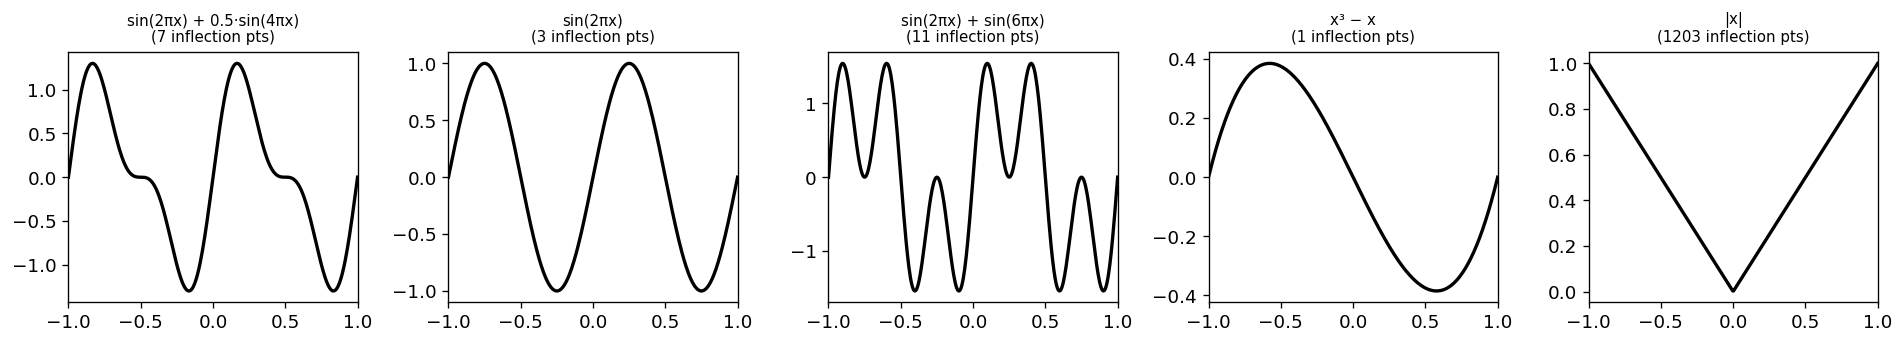

In [3]:
targets = {
    'sin(2πx) + 0.5·sin(4πx)':  lambda x: np.sin(2*np.pi*x) + 0.5*np.sin(4*np.pi*x),
    'sin(2πx)':                   lambda x: np.sin(2*np.pi*x),
    'sin(2πx) + sin(6πx)':        lambda x: np.sin(2*np.pi*x) + np.sin(6*np.pi*x),
    'x³ − x':                     lambda x: x**3 - x,
    '|x|':                         lambda x: np.abs(x),
}

# Preview targets
fig, axes = plt.subplots(1, len(targets), figsize=(16, 3))
x_plot = np.linspace(-1, 1, 400)
for ax, (name, f) in zip(axes, targets.items()):
    ax.plot(x_plot, f(x_plot), 'k-', lw=2)
    n_inf = count_inflection_points(f)
    ax.set_title(f'{name}\n({n_inf} inflection pts)', fontsize=9)
    ax.set_xlim([-1,1])
plt.tight_layout()
plt.savefig('../figures/target_functions.png', bbox_inches='tight')
plt.show()

## Run the Sweep

For each (target, m) pair, simulate to convergence and record the cluster count.

In [4]:
m_values = [20, 50, 100]
T = 60.0

rows = []
total = len(targets) * len(m_values)
done = 0

for name, f_star in targets.items():
    n_inf = count_inflection_points(f_star)
    for m in m_values:
        done += 1
        print(f"[{done}/{total}] target='{name}', m={m} ...", end=' ', flush=True)
        sol = run_simulation(m, f_star, T=T)
        b_final = sol.y[m:, -1]
        n_clust = count_clusters(b_final)
        loss = mse_loss(sol, f_star, m)
        rows.append({
            'Target': name,
            'm': m,
            'Clusters': n_clust,
            'Inflection pts': n_inf,
            'Clusters ≤ Inflections?': n_clust <= n_inf,
            'Final MSE': f'{loss:.5f}',
        })
        print(f"clusters={n_clust}, inflections={n_inf}, loss={loss:.5f}")

df = pd.DataFrame(rows)
print("\nDone.")

[1/15] target='sin(2πx) + 0.5·sin(4πx)', m=20 ... 

clusters=6, inflections=7, loss=0.15093
[2/15] target='sin(2πx) + 0.5·sin(4πx)', m=50 ... 

C:\Users\cal3b\AppData\Local\Temp\claude\ipykernel_32076\532139236.py:62: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(0.5 * np.trapz((f_vals - fstar)**2, X_QUAD))


clusters=12, inflections=7, loss=0.07531
[3/15] target='sin(2πx) + 0.5·sin(4πx)', m=100 ... 

clusters=18, inflections=7, loss=0.04643
[4/15] target='sin(2πx)', m=20 ... 

...

clusters=33, inflections=1, loss=0.00038
[12/15] target='x³ − x', m=100 ... 

clusters=43, inflections=1, loss=0.00026
[13/15] target='|x|', m=20 ... 

clusters=16, inflections=1203, loss=0.00039
[14/15] target='|x|', m=50 ... 

clusters=29, inflections=1203, loss=0.00075
[15/15] target='|x|', m=100 ... 

clusters=43, inflections=1203, loss=0.00124

Done.


## Results Table

In [5]:
pd.set_option('display.max_colwidth', 40)
display(df)
df.to_csv('../data/cluster_count_sweep.csv', index=False)
print("Saved to ../data/cluster_count_sweep.csv")

,Target,m,Clusters,Inflection pts,Clusters ≤ Inflections?,Final MSE
0,sin(2πx) + 0.5·sin(4πx),20,6,7,True,0.15093
1,sin(2πx) + 0.5·sin(4πx),50,12,7,False,0.07531
2,sin(2πx) + 0.5·sin(4πx),100,18,7,False,0.04643
3,sin(2πx),20,7,3,False,0.12346
4,sin(2πx),50,9,3,False,0.03689
5,sin(2πx),100,26,3,False,0.01442
6,sin(2πx) + sin(6πx),20,8,11,True,0.55464
7,sin(2πx) + sin(6πx),50,13,11,False,0.45297
8,sin(2πx) + sin(6πx),100,14,11,False,0.38698
9,x³ − x,20,20,1,False,0.00072


Saved to ../data/cluster_count_sweep.csv


## Visualization: Clusters vs Inflection Points

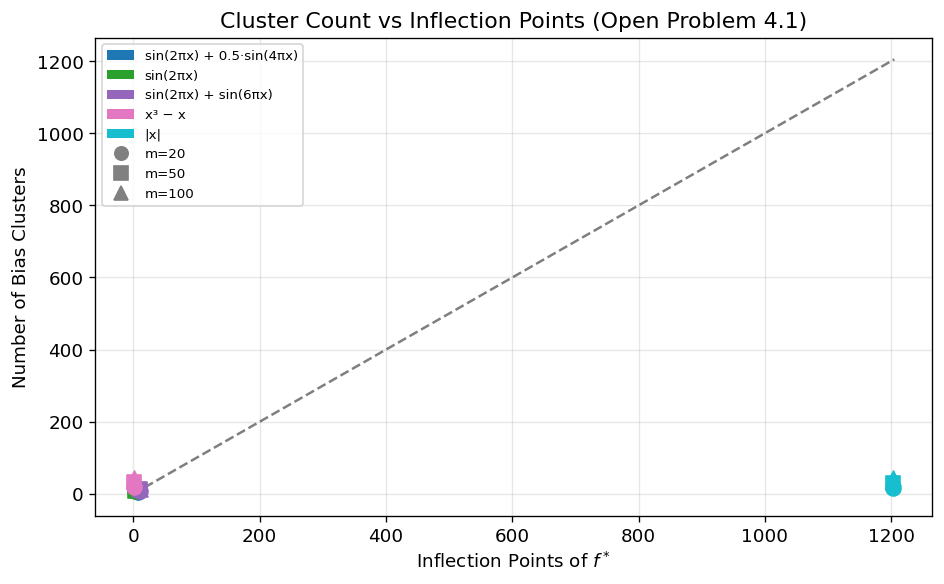

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = plt.cm.tab10(np.linspace(0, 0.9, len(targets)))
markers = ['o', 's', '^']

for (name, f_star), color in zip(targets.items(), colors):
    sub = df[df['Target'] == name]
    n_inf = count_inflection_points(f_star)
    for i, row in sub.iterrows():
        m_idx = m_values.index(row['m'])
        ax.scatter(n_inf, row['Clusters'], color=color,
                   marker=markers[m_idx], s=80, zorder=5)

# y=x reference line
max_val = max(df['Inflection pts'].max(), df['Clusters'].max()) + 2
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Clusters = Inflections')

# Legend for targets
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elems = [Patch(facecolor=c, label=n) for n, c in zip(targets.keys(), colors)]
legend_elems += [Line2D([0],[0],marker=markers[i],color='gray',
                         linestyle='None',markersize=8,label=f'm={mv}')
                 for i, mv in enumerate(m_values)]
ax.legend(handles=legend_elems, fontsize=8, loc='upper left')

ax.set_xlabel('Inflection Points of $f^*$')
ax.set_ylabel('Number of Bias Clusters')
ax.set_title('Cluster Count vs Inflection Points (Open Problem 4.1)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/cluster_count_sweep.png', bbox_inches='tight')
plt.show()

## Bias Trajectory Grid: One Plot per Target (m=50)

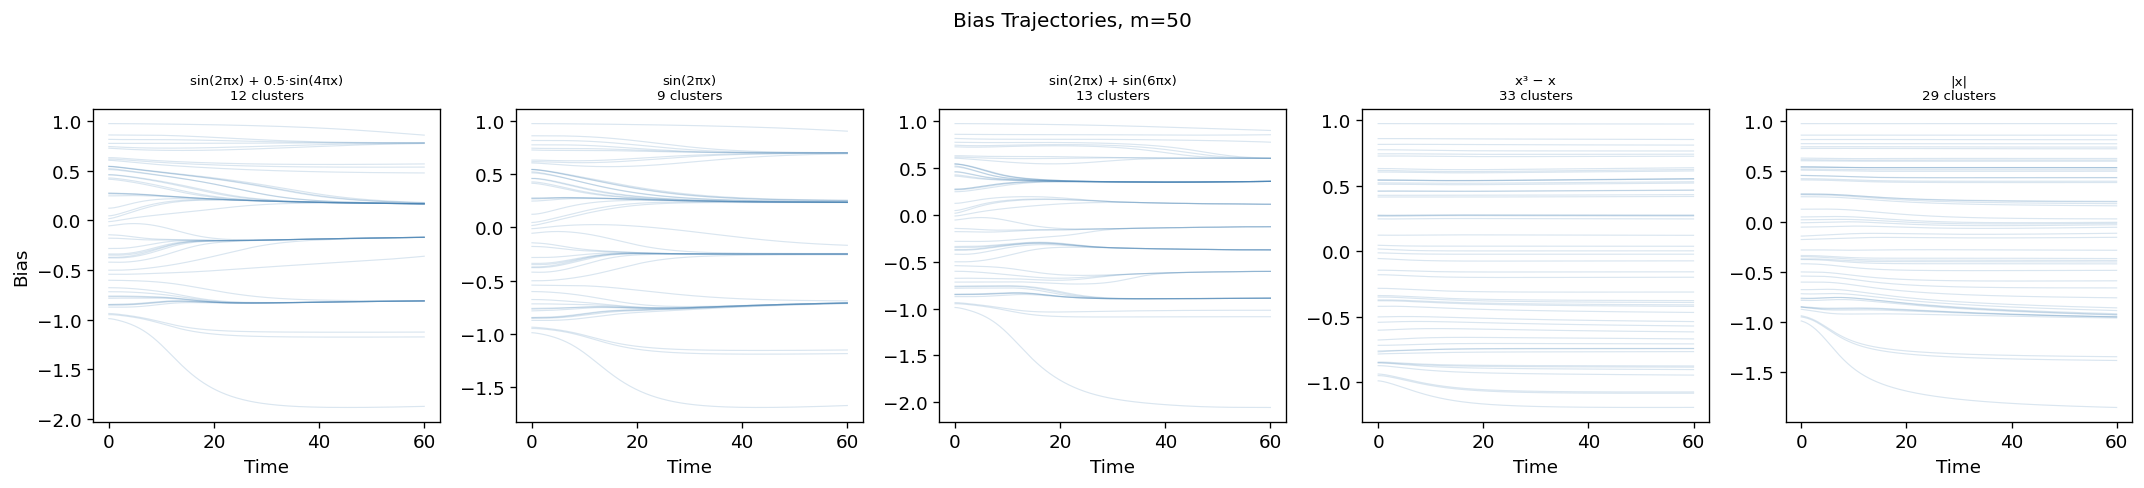

In [7]:
m_fixed = 50
fig, axes = plt.subplots(1, len(targets), figsize=(18, 4), sharey=False)

for ax, (name, f_star) in zip(axes, targets.items()):
    sol = run_simulation(m_fixed, f_star, T=T, n_save=300)
    biases = np.sort(sol.y[m_fixed:, :], axis=0)
    for j in range(m_fixed):
        ax.plot(sol.t, biases[j], color='steelblue', alpha=0.2, linewidth=0.7)
    n_clust = count_clusters(sol.y[m_fixed:, -1])
    ax.set_title(f'{name}\n{n_clust} clusters', fontsize=8)
    ax.set_xlabel('Time')
    if ax == axes[0]:
        ax.set_ylabel('Bias')

plt.suptitle(f'Bias Trajectories, m={m_fixed}', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../figures/bias_trajectories_all_targets.png', bbox_inches='tight')
plt.show()